# 02 — ベースライン: PLS回帰

近赤外ケモメトリクスの標準手法であるPLS（部分的最小二乗回帰）でベースラインスコアを確立する。

**方針**
- 前処理の種類（SNV / MSC / SG微分）を比較
- GroupKFold で species number 単位のCV（テストと同じ条件を模倣）
- n_components を最適化

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupKFold

from src.utils import load_data, parse_spectra, get_groups, rmse, make_submission, setup_japanese_font
from src.preprocessing import apply_preprocessing

plt.rcParams['figure.dpi'] = 110
font_used = setup_japanese_font()
print(f'Japanese font: {font_used}')

train_df, test_df = load_data()
train_meta, y_train, X_train_raw, wn = parse_spectra(train_df)
test_meta,  _,       X_test_raw,  _  = parse_spectra(test_df)

groups = get_groups(train_meta)
print('train:', X_train_raw.shape, '  species groups:', np.unique(groups))

Japanese font: Noto Sans JP
train: (1322, 1555)   species groups: [ 1  3  4  5  8 11 12 13 14 15 16 17 19]


## 1. 前処理の比較（5-fold GroupKFold CV）

In [2]:
N_COMPONENTS = 10
N_SPLITS = 5

results = {}
for method in ['raw', 'snv', 'msc', 'sg1', 'sg2', 'snv+sg1', 'snv+sg2']:
    X = apply_preprocessing(X_train_raw, method=method)
    scores = []
    for tr, va in GroupKFold(n_splits=N_SPLITS).split(X, y_train, groups):
        pls = PLSRegression(n_components=N_COMPONENTS, scale=False)
        pls.fit(X[tr], y_train.values[tr])
        scores.append(rmse(y_train.values[va], pls.predict(X[va]).ravel()))
    results[method] = np.mean(scores)
    print(f'{method:12s}  CV RMSE = {results[method]:.4f}')

best_method = min(results, key=results.get)
print(f'\nBest preprocessing: {best_method}  (RMSE={results[best_method]:.4f})')

raw           CV RMSE = 37.0317
snv           CV RMSE = 165.9460
msc           CV RMSE = 164.9946
sg1           CV RMSE = 81.8120
sg2           CV RMSE = 66.4588
snv+sg1       CV RMSE = 108.0655
snv+sg2       CV RMSE = 47.2221

Best preprocessing: raw  (RMSE=37.0317)


## 2. n_components の最適化

最適 n_components = 3  (RMSE=30.4378)


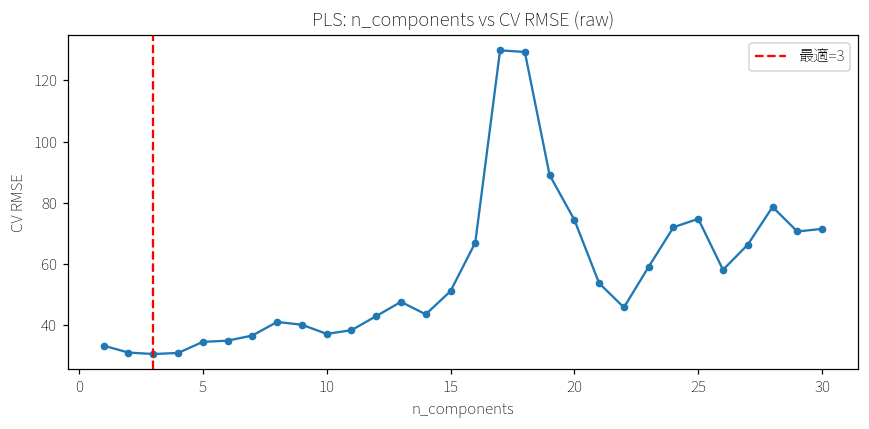

In [ ]:
X = apply_preprocessing(X_train_raw, method=best_method)

component_range = list(range(1, 31))
cv_scores = []
for n in component_range:
    scores = []
    for tr, va in GroupKFold(n_splits=N_SPLITS).split(X, y_train, groups):
        pls = PLSRegression(n_components=n, scale=False)
        pls.fit(X[tr], y_train.values[tr])
        scores.append(rmse(y_train.values[va], pls.predict(X[va]).ravel()))
    cv_scores.append(np.mean(scores))

best_n = component_range[int(np.argmin(cv_scores))]
print(f'最適 n_components = {best_n}  (RMSE={min(cv_scores):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(component_range, cv_scores, marker='o', markersize=4)
plt.axvline(best_n, color='r', linestyle='--', label=f'最適={best_n}')
plt.xlabel('n_components')
plt.ylabel('CV RMSE')
plt.title(f'PLS: n_components vs CV RMSE ({best_method})')
plt.legend()
plt.tight_layout()
plt.show()

## 3. 最終モデルの学習 & 提出ファイル生成

In [ ]:
X_train = apply_preprocessing(X_train_raw, method=best_method)
X_test  = apply_preprocessing(X_test_raw,  method=best_method)

pls_final = PLSRegression(n_components=best_n, scale=False)
pls_final.fit(X_train, y_train)

train_pred = pls_final.predict(X_train).ravel()
print(f'訓練RMSE（in-sample）: {rmse(y_train, train_pred):.4f}')

test_pred = pls_final.predict(X_test).ravel()
print(f'テスト予測: min={test_pred.min():.2f}  max={test_pred.max():.2f}')

sub = make_submission(test_meta, test_pred, path='../submissions/pls_baseline.csv')
sub.head()

訓練RMSE（in-sample）: 24.5801
テスト予測: min=18.50  max=197.74
Saved submission: ../submissions/pls_baseline.csv


,sample_number,moisture
0,95,197.742163
1,96,182.771761
2,97,173.340203
3,98,166.375316
4,99,157.246729


## 4. モデルの解釈: VIP スコア

VIP (Variable Importance in Projection) が 1.0 を超える波数が重要な変数。

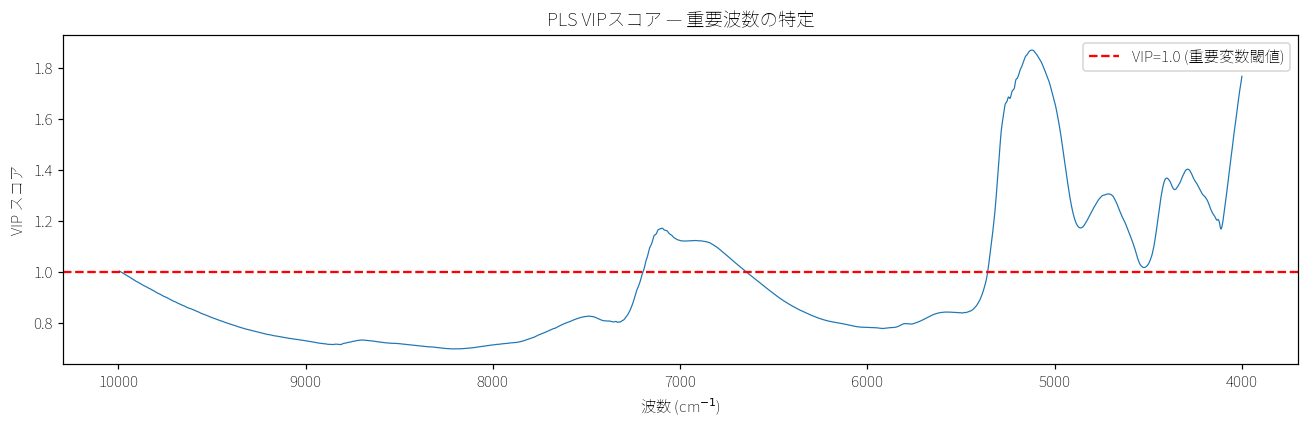

VIP>1.0 の波数数: 499 / 1555


In [ ]:
def vip_scores(model):
    t = model.x_scores_
    w = model.x_weights_
    q = model.y_loadings_
    p = w.shape[0]
    ss = (t ** 2).sum(axis=0) * (q ** 2).sum(axis=0)
    vip = np.sqrt(p * ((w / np.linalg.norm(w, axis=0)) ** 2 @ ss) / ss.sum())
    return vip

vip = vip_scores(pls_final)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wn, vip, linewidth=0.8)
ax.axhline(1.0, color='r', linestyle='--', label='VIP=1.0 (重要変数閾値)')
ax.set_xlabel('波数 (cm$^{-1}$)')
ax.set_ylabel('VIP スコア')
ax.set_title('PLS VIPスコア — 重要波数の特定')
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.show()

print(f'VIP>1.0 の波数数: {(vip > 1.0).sum()} / {len(wn)}')

## 5. 残差分析

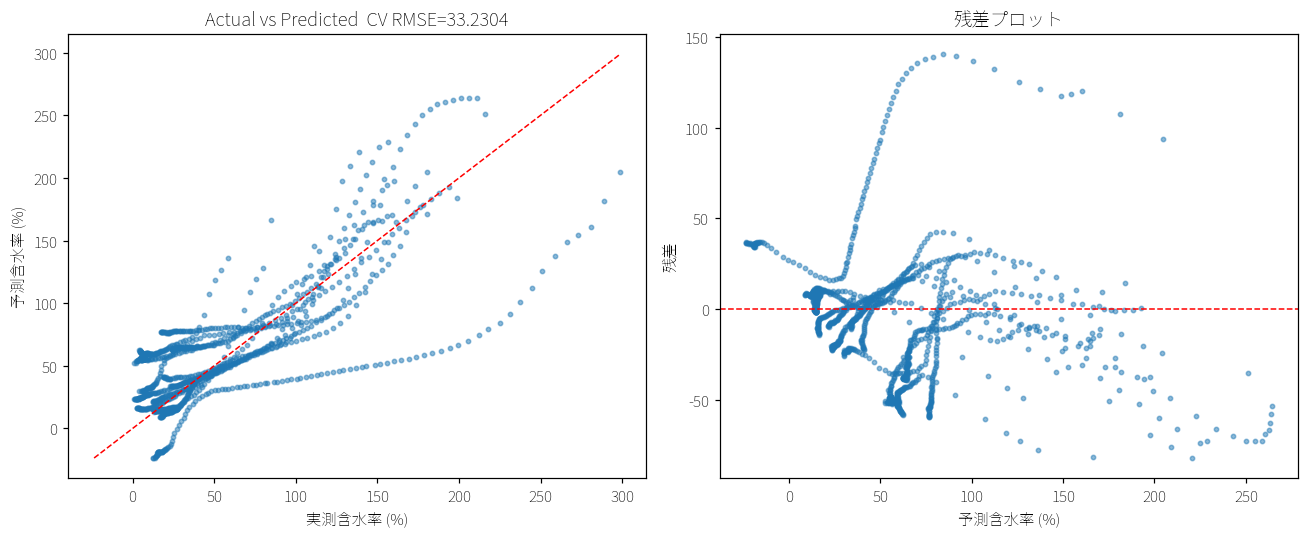

In [ ]:
X = apply_preprocessing(X_train_raw, method=best_method)
cv_pred = np.zeros(len(y_train))
for tr, va in GroupKFold(n_splits=N_SPLITS).split(X, y_train, groups):
    pls = PLSRegression(n_components=best_n, scale=False)
    pls.fit(X[tr], y_train.values[tr])
    cv_pred[va] = pls.predict(X[va]).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_train, cv_pred, s=8, alpha=0.5)
lims = [min(y_train.min(), cv_pred.min()), max(y_train.max(), cv_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('実測含水率 (%)')
axes[0].set_ylabel('予測含水率 (%)')
axes[0].set_title(f'Actual vs Predicted  CV RMSE={rmse(y_train, cv_pred):.4f}')

residuals = y_train.values - cv_pred
axes[1].scatter(cv_pred, residuals, s=8, alpha=0.5)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_xlabel('予測含水率 (%)')
axes[1].set_ylabel('残差')
axes[1].set_title('残差プロット')

plt.tight_layout()
plt.show()